# Hand Gesture Recognition — Baseline Training

**Track B: Open/Public Dataset (HGAG-DATA)**

This notebook trains and evaluates baseline classifiers on DWT-transformed accelerometer and gyroscope data for 11 hand gesture classes.

## 1. Library Versions & Imports

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import sys, os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 150, "font.size": 10})

# ---------- version info ----------
print(f"Python      : {sys.version}")
print(f"NumPy       : {np.__version__}")
print(f"Pandas      : {pd.__version__}")
import sklearn; print(f"Scikit-learn: {sklearn.__version__}")
print(f"Matplotlib  : {matplotlib.__version__}")
print(f"Seaborn     : {sns.__version__}")

Python      : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
NumPy       : 2.0.2
Pandas      : 2.2.2
Scikit-learn: 1.6.1
Matplotlib  : 3.10.0
Seaborn     : 0.13.2


## 2. Dataset Loading


In [ ]:
import os
import shutil

ZIP_PATH = "/content/drive/MyDrive/TinyML-Project/dataset.zip"
LOCAL_EXTRACT_ROOT = "/content/tinyml_data"

if os.path.exists(LOCAL_EXTRACT_ROOT):
    print("Removing old local extracted dataset...")
    shutil.rmtree(LOCAL_EXTRACT_ROOT)

os.makedirs(LOCAL_EXTRACT_ROOT, exist_ok=True)

print("Unzipping dataset from Drive ZIP to local runtime...")
!unzip -q "{ZIP_PATH}" -d "{LOCAL_EXTRACT_ROOT}"
print("Unzip complete.")

Unzipping dataset from Drive ZIP to local runtime...
Unzip complete.


In [ ]:
import os
import numpy as np
import pandas as pd

candidates = [
    "/content/tinyml_data/data",
    "/content/tinyml_data/HGAG-DATA",
    "/content/tinyml_data"
]

DATA_ROOT = None
for c in candidates:
    if os.path.exists(os.path.join(c, "train")) and os.path.exists(os.path.join(c, "val")):
        DATA_ROOT = c
        break

if DATA_ROOT is None:
    raise FileNotFoundError("Could not find dataset root containing train/val/test after unzip.")

TRAIN_DIR = os.path.join(DATA_ROOT, "train")
VAL_DIR   = os.path.join(DATA_ROOT, "val")
TEST_DIR  = os.path.join(DATA_ROOT, "test")

CHANNELS = ["accel_x", "accel_y", "accel_z", "gyro_x", "gyro_y", "gyro_z"]
CHANNEL_FILES = [f"{ch}_data.csv" for ch in CHANNELS]

print("DATA_ROOT:", DATA_ROOT)
print("TRAIN exists:", os.path.exists(TRAIN_DIR))
print("VAL exists  :", os.path.exists(VAL_DIR))
print("TEST exists :", os.path.exists(TEST_DIR))

GESTURE_CLASSES = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
])

NUM_CLASSES = len(GESTURE_CLASSES)
print(f"Gesture classes ({NUM_CLASSES}): {GESTURE_CLASSES}")

DATA_ROOT: /content/tinyml_data/data
TRAIN exists: True
VAL exists  : True
TEST exists : True
Gesture classes (11): ['Clapping', 'Coin Flipping', 'Finger Snapping', 'Fist Making', 'Horizontal Wrist Extension', 'Index Finger Flick', 'Index Thumb Tap', 'Shooting', 'Thumb Up', 'Wrist Extension', 'Wrist Flexion']


In [ ]:
def load_split_detailed(split_dir, gesture_classes, channel_files):
    """Load data and also track which subject each trial came from."""
    X_list, y_list, subj_list = [], [], []

    for gesture_idx, gesture in enumerate(gesture_classes):
        gesture_dir = os.path.join(split_dir, gesture)
        if not os.path.isdir(gesture_dir):
            continue

        for subject in sorted(os.listdir(gesture_dir)):
            subject_dir = os.path.join(gesture_dir, subject, ".csv")
            if not os.path.isdir(subject_dir):
                continue

            channel_data = []
            valid_subject = True

            for ch_file in channel_files:
                filepath = os.path.join(subject_dir, ch_file)

                if not os.path.exists(filepath):
                    print(f"Missing file: {filepath}")
                    valid_subject = False
                    break

                data = np.loadtxt(filepath, delimiter=",", dtype=np.float32)

                if data.ndim == 1:
                    data = data.reshape(1, -1)

                channel_data.append(data)

            if not valid_subject:
                continue

            features = np.concatenate(channel_data, axis=1)
            n_trials = features.shape[0]

            X_list.append(features)
            y_list.extend([gesture_idx] * n_trials)
            subj_list.extend([subject] * n_trials)

    return np.vstack(X_list), np.array(y_list), np.array(subj_list)

In [ ]:
X_train, y_train, subj_train = load_split_detailed(TRAIN_DIR, GESTURE_CLASSES, CHANNEL_FILES)
X_val,   y_val,   subj_val   = load_split_detailed(VAL_DIR,   GESTURE_CLASSES, CHANNEL_FILES)
X_test,  y_test,  subj_test  = load_split_detailed(TEST_DIR,  GESTURE_CLASSES, CHANNEL_FILES)

print(f"Train : X={X_train.shape}, y={y_train.shape}")
print(f"Val   : X={X_val.shape}, y={y_val.shape}")
print(f"Test  : X={X_test.shape}, y={y_test.shape}")
print(f"Feature dimension: {X_train.shape[1]}")

Train : X=(17050, 1500), y=(17050,)
Val   : X=(3298, 1500), y=(3298,)
Test  : X=(3300, 1500), y=(3300,)
Feature dimension: 1500


## 3. Class Distribution

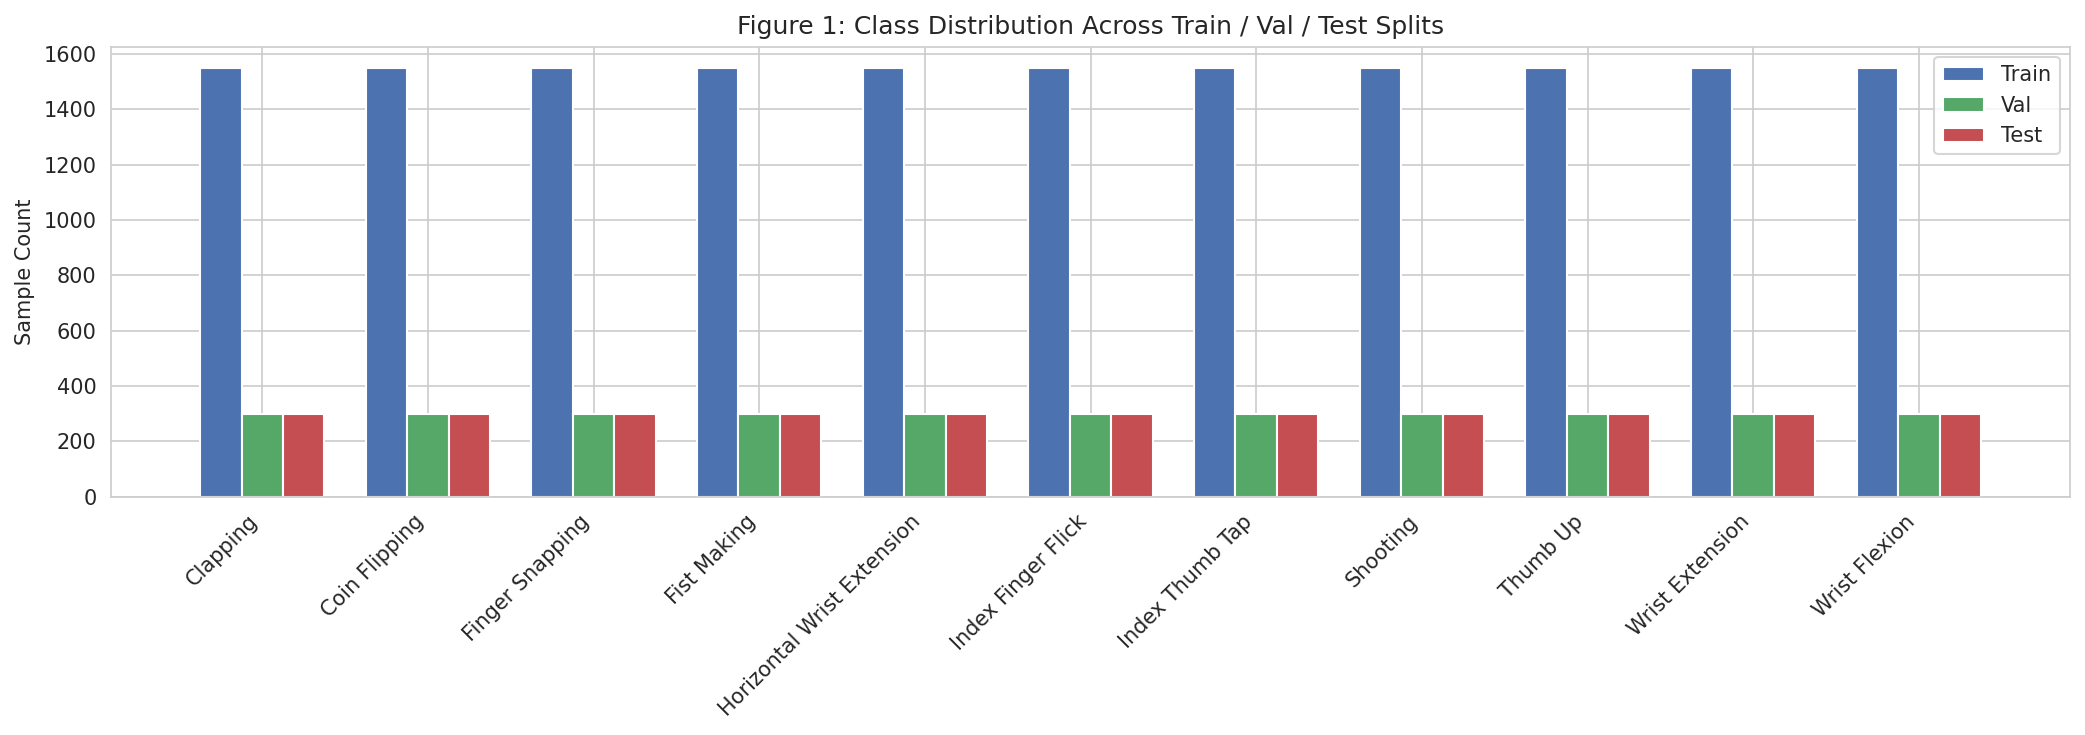

In [9]:
# === per-class distribution table ===
train_counts = pd.Series(y_train).value_counts().sort_index()
val_counts   = pd.Series(y_val).value_counts().sort_index()
test_counts  = pd.Series(y_test).value_counts().sort_index()

class_distribution_df = pd.DataFrame({
    "Class Index": range(NUM_CLASSES),
    "Gesture Class": GESTURE_CLASSES,
    "Train Samples": train_counts.reindex(range(NUM_CLASSES), fill_value=0).values,
    "Val Samples": val_counts.reindex(range(NUM_CLASSES), fill_value=0).values,
    "Test Samples": test_counts.reindex(range(NUM_CLASSES), fill_value=0).values,
})

class_distribution_df["Total Samples"] = (
    class_distribution_df["Train Samples"] +
    class_distribution_df["Val Samples"] +
    class_distribution_df["Test Samples"]
)

# ── visual: class distribution bar chart ──
fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(NUM_CLASSES)
width = 0.25

# remove TOTAL row if it exists
plot_df = class_distribution_df.copy()

# bars
ax.bar(x - width, plot_df["Train Samples"], width, label="Train", color="#4c72b0")
ax.bar(x,         plot_df["Val Samples"],   width, label="Val",   color="#55a868")
ax.bar(x + width, plot_df["Test Samples"],  width, label="Test",  color="#c44e52")

# labels
ax.set_xticks(x)
ax.set_xticklabels(GESTURE_CLASSES, rotation=45, ha="right")

ax.set_ylabel("Sample Count")
ax.set_title("Figure 1: Class Distribution Across Train / Val / Test Splits")
ax.legend()

plt.tight_layout()
plt.savefig("fig1_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Split Verification
Subject-Level split

In [10]:
total = len(y_train) + len(y_val) + len(y_test)
print(f"Train: {len(y_train):>5} samples ({100*len(y_train)/total:.1f}%)")
print(f"Val  : {len(y_val):>5} samples ({100*len(y_val)/total:.1f}%)")
print(f"Test : {len(y_test):>5} samples ({100*len(y_test)/total:.1f}%)")
print(f"Total: {total:>5} samples")

Train: 17050 samples (72.1%)
Val  :  3298 samples (13.9%)
Test :  3300 samples (14.0%)
Total: 23648 samples


## 5. Preprocessing

In [11]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

print("Label mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i:>2}: {cls}")

print(f"\nTrain scaled mean: {X_train_sc.mean():.6f}")
print(f"Train scaled std : {X_train_sc.std():.6f}")

Label mapping:
   0: 0
   1: 1
   2: 2
   3: 3
   4: 4
   5: 5
   6: 6
   7: 7
   8: 8
   9: 9
  10: 10

Train scaled mean: 0.000000
Train scaled std : 1.000000


## 6. Baseline Models — Training

Random Forest: n =200
SVM: rbf, c=10
KNN: k=5
Dense NN

In [12]:
def evaluate_model(name, y_true, y_pred, le):
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    print(f"\n{'='*50}")
    print(f"{name}")
    print(f"{'='*50}")
    print(f"  Accuracy   : {acc:.4f}")
    print(f"  Macro F1   : {macro_f1:.4f}")
    print(f"  Weighted F1: {weighted_f1:.4f}")
    return {"name": name, "accuracy": acc, "macro_f1": macro_f1, "weighted_f1": weighted_f1}

results = []
predictions = {}

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200, max_depth=30, min_samples_split=5,
    min_samples_leaf=2, max_features="sqrt", random_state=42,
    n_jobs=-1, class_weight="balanced"
)
rf.fit(X_train_sc, y_train_enc)
y_pred_rf = rf.predict(X_test_sc)
results.append(evaluate_model("Random Forest", y_test_enc, y_pred_rf, le))
predictions["Random Forest"] = y_pred_rf


Random Forest
  Accuracy   : 0.6173
  Macro F1   : 0.6205
  Weighted F1: 0.6205


In [14]:
from sklearn.svm import SVC

svm = SVC(kernel="rbf", C=10, gamma="scale", random_state=42, class_weight="balanced")
svm.fit(X_train_sc, y_train_enc)
y_pred_svm = svm.predict(X_test_sc)
results.append(evaluate_model("SVM", y_test_enc, y_pred_svm, le))
predictions["SVM"] = y_pred_svm


SVM
  Accuracy   : 0.7058
  Macro F1   : 0.7063
  Weighted F1: 0.7063


In [15]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
knn.fit(X_train_sc, y_train_enc)
y_pred_knn = knn.predict(X_test_sc)
results.append(evaluate_model("k-NN", y_test_enc, y_pred_knn, le))
predictions["k-NN"] = y_pred_knn


k-NN
  Accuracy   : 0.3927
  Macro F1   : 0.4091
  Weighted F1: 0.4091


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       384,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │           715 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 426,123 (1.63 MB)

 Trainable params: 426,123 (1.63 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
533/533 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.3097 - loss: 1.9254 - val_accuracy: 0.4861 - val_loss: 1.3407
Epoch 2/50
533/533 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4959 - loss: 1.3191 - val_accuracy: 0.5600 - val_loss: 1.1361
Epoch 3/50
533/533 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5755 - loss: 1.0809 - val_accuracy: 0.5949 - val_loss: 1.0635
Epoch 4/50
533/533 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6304 - loss: 0.9577 - val_accuracy: 0.6207 - val_loss: 0.9912
Epoch 5/50
533/533 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6639 - loss: 0.8618 - val_accuracy: 0.6255 - val_loss: 0.9738
Epoch 6/50
533/533 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6891 - loss: 0.8030 - val_accuracy: 0.6246 - val_loss: 1.0056
Epoch 7/50
533/533 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7097 - loss: 0.7543 - val_accuracy: 0.6431 - val_loss: 0.9521
Epoch 8/50
533/533 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7297 - loss: 0.7018 - val_accuracy: 

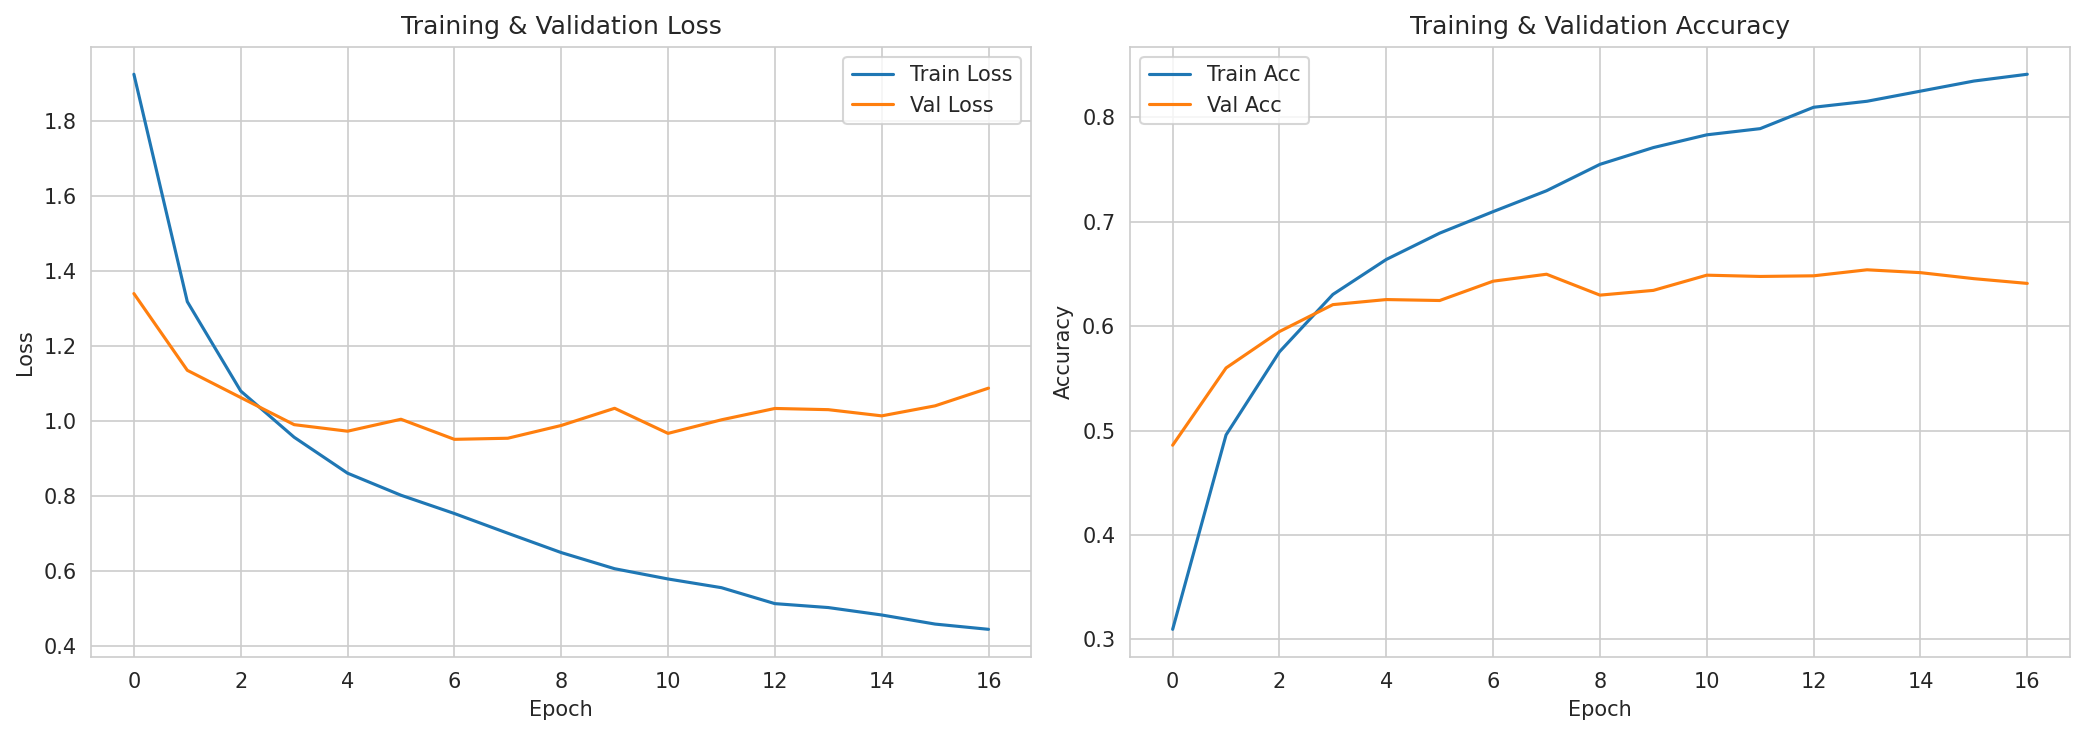

104/104 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step

Dense NN
  Accuracy   : 0.6836
  Macro F1   : 0.6807
  Weighted F1: 0.6807


In [16]:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

model = Sequential([
    Input(shape=(1500,)),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

early_stop = EarlyStopping(
    monitor="val_loss", patience=10, restore_best_weights=True
)

history = model.fit(
    X_train_sc, y_train_enc,
    validation_data=(X_val_sc, y_val_enc),
    epochs=50, batch_size=32,
    callbacks=[early_stop], verbose=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history["loss"], label="Train Loss")
axes[0].plot(history.history["val_loss"], label="Val Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training & Validation Loss")
axes[0].legend()

axes[1].plot(history.history["accuracy"], label="Train Acc")
axes[1].plot(history.history["val_accuracy"], label="Val Acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Training & Validation Accuracy")
axes[1].legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()

y_pred_nn = model.predict(X_test_sc).argmax(axis=1)
results.append(evaluate_model("Dense NN", y_test_enc, y_pred_nn, le))
predictions["Dense NN"] = y_pred_nn

## 7. Model Comparison Summary

In [17]:
print(f"{'Model':<15} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("-" * 49)
for r in results:
    print(f"{r['name']:<15} {r['accuracy']:>10.4f} {r['macro_f1']:>10.4f} {r['weighted_f1']:>12.4f}")

print(f"\nTest set size  : {len(y_test_enc)}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Chance level   : {1/NUM_CLASSES:.4f} ({100/NUM_CLASSES:.1f}%)")

Model             Accuracy   Macro F1  Weighted F1
-------------------------------------------------
Random Forest       0.6173     0.6205       0.6205
SVM                 0.7058     0.7063       0.7063
k-NN                0.3927     0.4091       0.4091
Dense NN            0.6836     0.6807       0.6807

Test set size  : 3300
Number of classes: 11
Chance level   : 0.0909 (9.1%)


## 8. Best Model — Detailed Test-Set Evaluation

In [18]:
best = max(results, key=lambda r: r["macro_f1"])
best_name = best["name"]
y_pred_best = predictions[best_name]

print(f"Best F1: {best_name} ({best['macro_f1']:.4f})")

Best F1: SVM (0.7063)


In [20]:
print(classification_report(
    y_test_enc, y_pred_best,
    target_names=GESTURE_CLASSES,
    digits=4
))

                            precision    recall  f1-score   support

                  Clapping     0.7057    0.9433    0.8074       300
             Coin Flipping     0.5607    0.7233    0.6317       300
           Finger Snapping     0.5924    0.4167    0.4892       300
               Fist Making     0.4709    0.8367    0.6026       300
Horizontal Wrist Extension     0.9791    0.9367    0.9574       300
        Index Finger Flick     0.6352    0.6733    0.6537       300
           Index Thumb Tap     0.9571    0.8933    0.9241       300
                  Shooting     0.8000    0.5067    0.6204       300
                  Thumb Up     0.6321    0.6700    0.6505       300
           Wrist Extension     0.9036    0.5933    0.7163       300
             Wrist Flexion     0.9607    0.5700    0.7155       300

                  accuracy                         0.7058      3300
                 macro avg     0.7452    0.7058    0.7063      3300
              weighted avg     0.7452    0.705

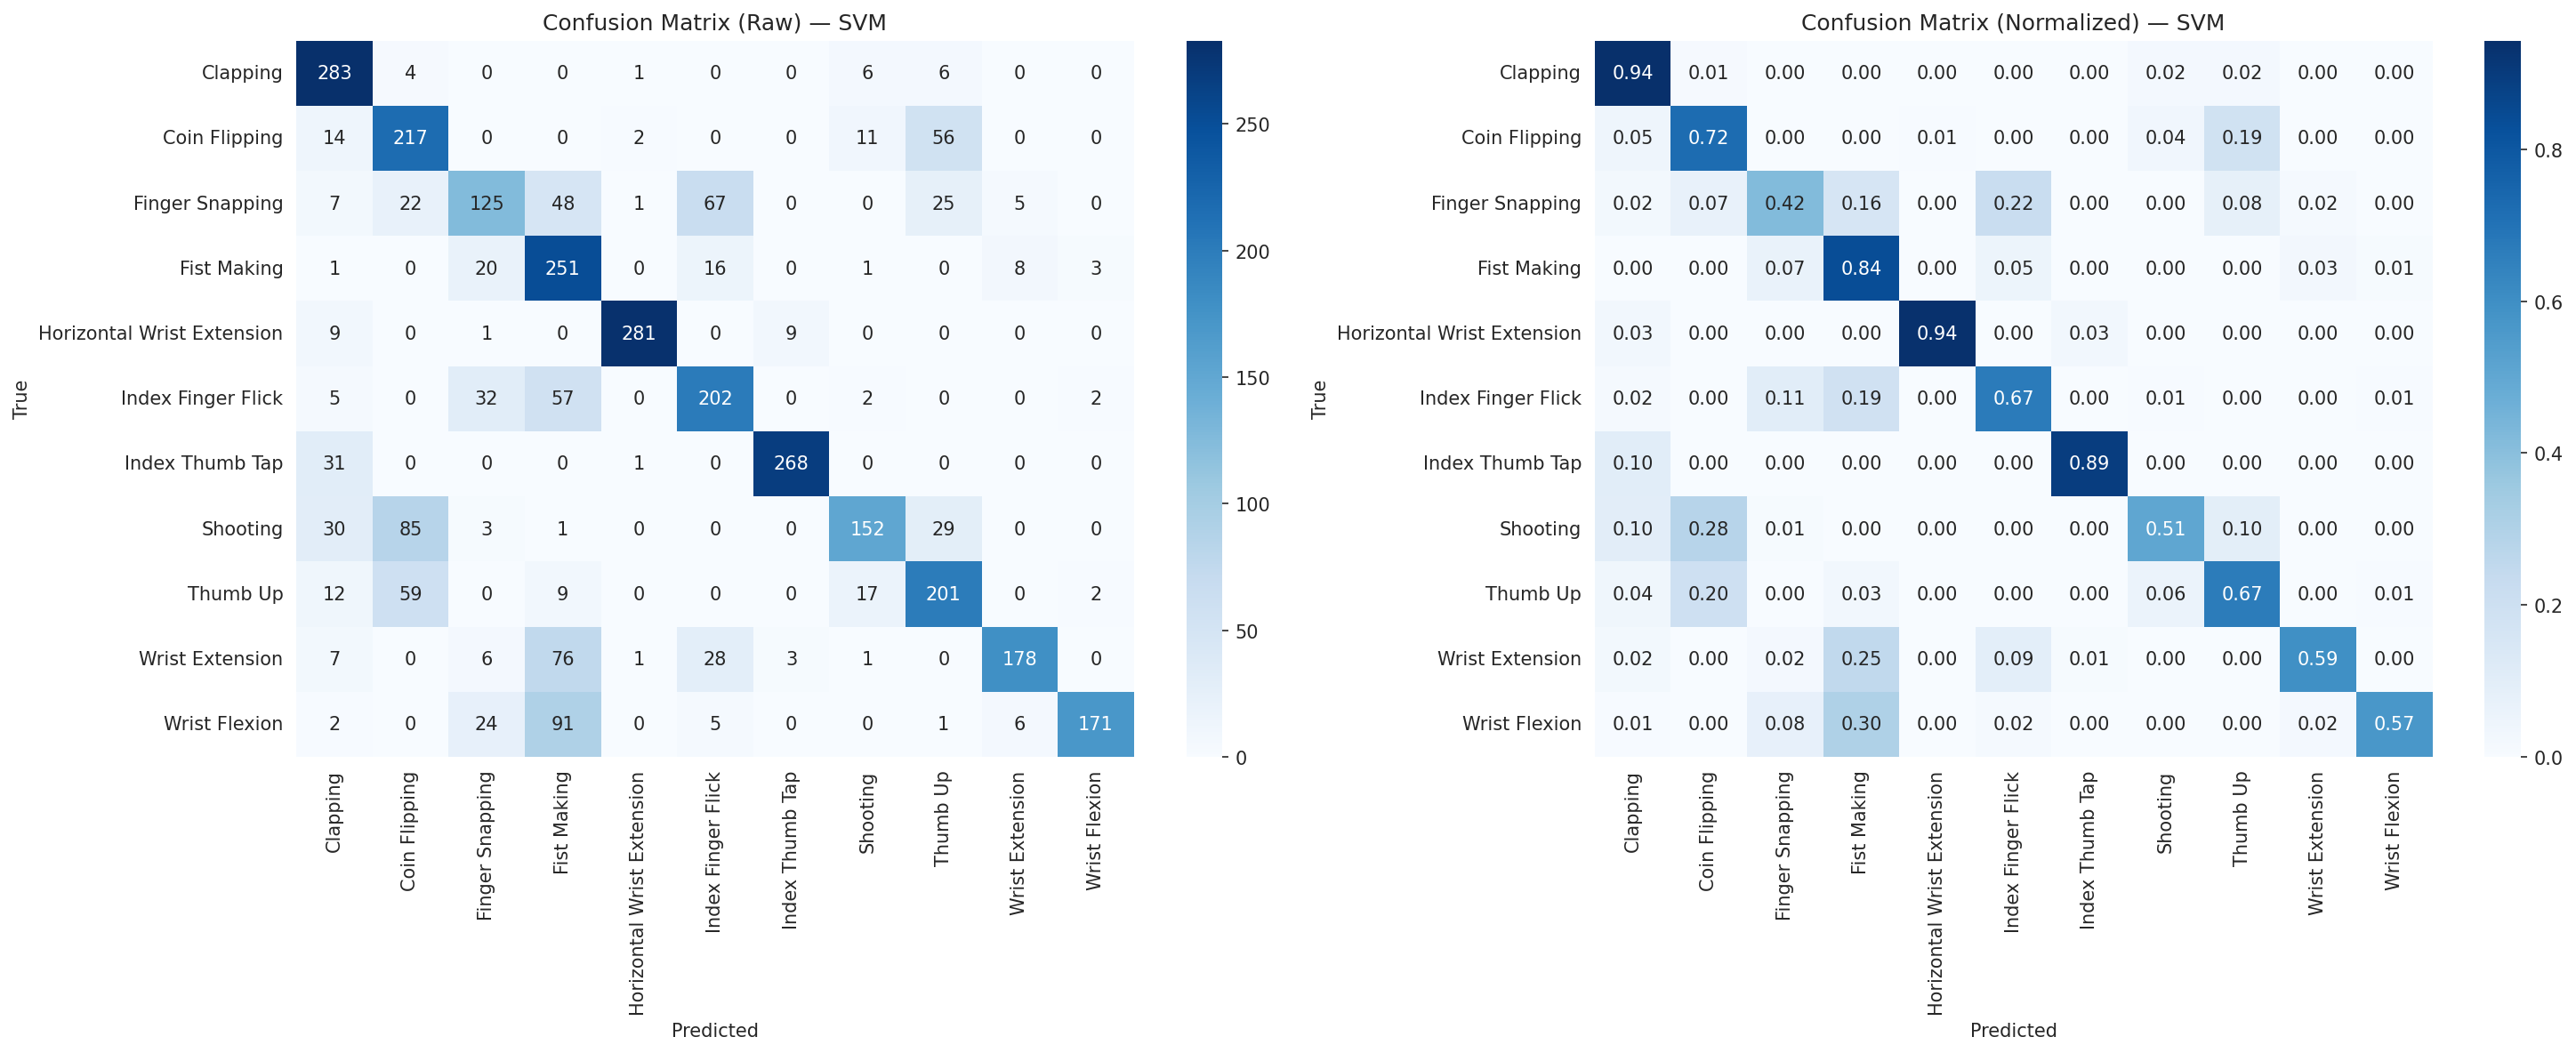

In [25]:
cm = confusion_matrix(y_test_enc, y_pred_best)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=GESTURE_CLASSES, yticklabels=GESTURE_CLASSES, ax=axes[0])
axes[0].set_title(f"Confusion Matrix (Raw) — {best_name}")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", xticklabels=GESTURE_CLASSES, yticklabels=GESTURE_CLASSES, ax=axes[1])
axes[1].set_title(f"Confusion Matrix (Normalized) — {best_name}")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

## 9. Error Analysis

In [26]:
confusion_pairs.append({
                "True": GESTURE_CLASSES[i],
                "Predicted": GESTURE_CLASSES[j],
                "Count": cm[i, j],
                "Error Rate": f"{cm[i, j] / cm[i].sum():.3f}"
            })

conf_df = pd.DataFrame(confusion_pairs).sort_values("Count", ascending=False).head(10)
print("Top 10 confusion pairs:")
print(conf_df.to_string(index=False))

Top 10 confusion pairs:
         True     Predicted  Count Error Rate
Wrist Flexion Wrist Flexion    171      0.570
           10             3     91        NaN
            7             1     85        NaN
            9             3     76        NaN
            2             5     67        NaN
            8             1     59        NaN
            5             3     57        NaN
            1             8     56        NaN
            2             3     48        NaN
            5             2     32        NaN


In [27]:
per_class_acc = cm.diagonal() / cm.sum(axis=1)
acc_df = pd.DataFrame({"Class": GESTURE_CLASSES, "Accuracy": per_class_acc})
acc_df = acc_df.sort_values("Accuracy")

print("Per-class accuracy:")
print(acc_df.to_string(index=False))

print(f"\nWorst 3 classes:")
for _, row in acc_df.head(3).iterrows():
    print(f"  {row['Class']}: {row['Accuracy']:.4f}")

Per-class accuracy:
                     Class  Accuracy
           Finger Snapping  0.416667
                  Shooting  0.506667
             Wrist Flexion  0.570000
           Wrist Extension  0.593333
                  Thumb Up  0.670000
        Index Finger Flick  0.673333
             Coin Flipping  0.723333
               Fist Making  0.836667
           Index Thumb Tap  0.893333
Horizontal Wrist Extension  0.936667
                  Clapping  0.943333

Worst 3 classes:
  Finger Snapping: 0.4167
  Shooting: 0.5067
  Wrist Flexion: 0.5700


Feature importance by channel (Random Forest):
Channel  Mean Importance  Sum Importance
accel_x         0.000836        0.208893
accel_z         0.000813        0.203246
accel_y         0.000777        0.194164
 gyro_x         0.000596        0.148967
 gyro_y         0.000504        0.125960
 gyro_z         0.000475        0.118769


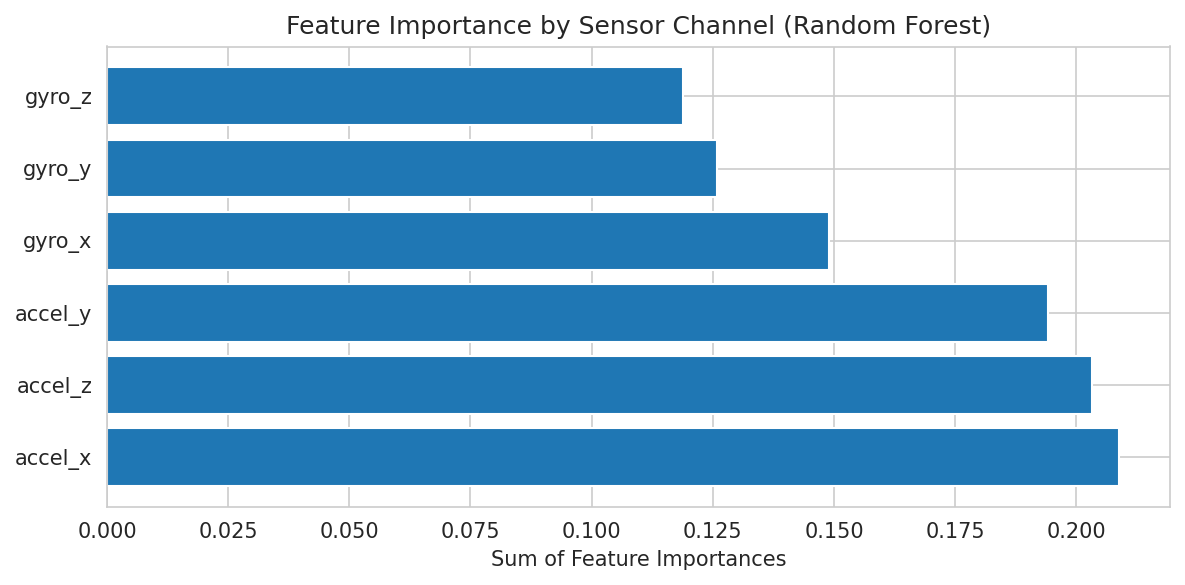

In [28]:
# ── Feature importance by channel (Random Forest, always computed) ──
importances = rf.feature_importances_
n_coeffs = X_train.shape[1] // len(CHANNELS)
channel_importance = []
for idx, ch in enumerate(CHANNELS):
    start = idx * n_coeffs
    end = start + n_coeffs
    channel_importance.append({
        "Channel": ch,
        "Mean Importance": importances[start:end].mean(),
        "Sum Importance": importances[start:end].sum()
    })

imp_df = pd.DataFrame(channel_importance).sort_values("Sum Importance", ascending=False)
print("Feature importance by channel (Random Forest):")
print(imp_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(imp_df["Channel"], imp_df["Sum Importance"])
ax.set_xlabel("Sum of Feature Importances")
ax.set_title("Feature Importance by Sensor Channel (Random Forest)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
